# (노트) Pytorch Linear Regression - 방법2

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [빅데이터분석]

### Import 

In [181]:
import torch
import numpy as np
import matplotlib.pyplot as plt 

### graphviz setting

In [182]:
import graphviz

`-` graphviz가 설치안되어 있다면 아래와 같은 방법으로 설치하라. (반드시 콘다로 설치해야함. pip로 설치하면 path를 따로 설정해줘야하더라) 
```
!conda install -c conda-forge graphviz -y 
```

`-` 아래와 같이 하면 다이어그램을 쉽게 쓸 수 있다. 

In [183]:
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"' + s + '; }')

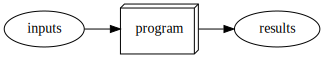

In [184]:
gv('''program[shape=box3d width=1 height=0.7]
inputs->program->results''')

### Data (Pytorch Linear Regression 방법1과 동일한 데이터 사용) 

`-` model: $y_i=w_0+w_1x_i+\epsilon_i=2.5+4x_i+\epsilon_i , \quad i=1,2,\dots,n $ 

`-` model: ${\bf y} = {\bf X} {\bf W} +\boldsymbol{\epsilon}$ 
 - ${\bf y}=\begin{bmatrix} y_1 \\ y_2 \\ \dots \\ y_n\end{bmatrix}, \quad  {\bf X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ .. \\ 1 & x_n \end{bmatrix}, \quad {\bf W}= \begin{bmatrix} 2.5 \\ 4 \end{bmatrix} $ 

In [185]:
torch.manual_seed(43052)
n = 100 
ones = torch.ones(n)
x,_ = torch.randn(n).sort()
X = torch.vstack([ones,x]).T
W = torch.tensor([2.5,4]) 
ϵ = torch.randn(n)*0.5

In [111]:
y=X@W+ϵ
ytrue=X@W

- ${\bf y}={\bf X W}+\boldsymbol{\epsilon}$ 
- ${\bf y}_{\tt ture}={\bf X W}$ 

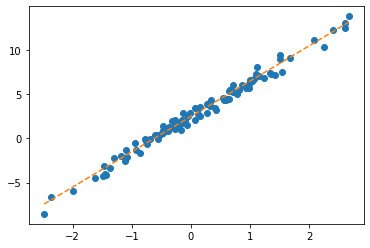

In [112]:
plt.plot(x,y,'o')
plt.plot(x,ytrue,'--')

### 이전방법요약 

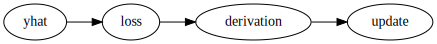

In [113]:
gv('''yhat -> loss -> derivation -> update''')

### step1: yhat

`-` feedforward 신경망을 설계함 

`-` 이 단계가 끝났다면, 아래와 같은 임의의 $\bf{\hat{W}}$을 넣었을때 ${\bf\hat{y}}$를 계산할 수 있어야 함. 

#### 방법1: 직접선언 (내가 공식을 알고 있을때) 

In [114]:
What = torch.tensor([-5.0,10.0],requires_grad=True)

In [115]:
yhat1=X@What
yhat1

tensor([-29.8211, -28.6215, -24.9730, -21.2394, -19.7919, -19.6354, -19.5093,
        -19.4352, -18.7223, -18.0793, -16.9040, -16.0918, -16.0536, -15.8746,
        -14.4690, -14.3193, -13.6426, -12.8578, -12.5486, -12.4213, -11.9484,
        -11.1034, -10.8296, -10.6210, -10.5064, -10.0578,  -9.8063,  -9.7380,
         -9.7097,  -9.6756,  -8.8736,  -8.7195,  -8.6880,  -8.1592,  -7.7752,
         -7.7716,  -7.7339,  -7.7208,  -7.6677,  -7.1551,  -7.0004,  -6.8163,
         -6.7081,  -6.5655,  -6.4480,  -6.3612,  -6.0566,  -5.6031,  -5.5589,
         -5.2137,  -4.3446,  -4.3165,  -3.8047,  -3.5801,  -3.4793,  -3.4325,
         -2.3545,  -2.3440,  -1.8434,  -1.7799,  -1.5386,  -1.0161,  -0.8103,
          0.4426,   0.5794,   0.9125,   1.1483,   1.4687,   1.4690,   1.5234,
          1.6738,   2.0592,   2.1414,   2.8221,   3.1536,   3.6682,   4.2907,
          4.8037,   4.8531,   4.9414,   5.3757,   5.3926,   5.6973,   6.0239,
          6.1261,   6.5317,   7.2891,   8.4032,   8.4936,   9.27

#### 방법2: torch.nn.Linear() 사용, bias=False

In [116]:
net = torch.nn.Linear(in_features=2,out_features=1,bias=False)

In [117]:
net.weight

Parameter containing:
tensor([[0.3320, 0.1982]], requires_grad=True)

In [118]:
net.weight.data=torch.tensor([[-5.0,10.0]])
net.weight

Parameter containing:
tensor([[-5., 10.]], requires_grad=True)

In [119]:
net(X)

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919],
        [-19.6354],
        [-19.5093],
        [-19.4352],
        [-18.7223],
        [-18.0793],
        [-16.9040],
        [-16.0918],
        [-16.0536],
        [-15.8746],
        [-14.4690],
        [-14.3193],
        [-13.6426],
        [-12.8578],
        [-12.5486],
        [-12.4213],
        [-11.9484],
        [-11.1034],
        [-10.8296],
        [-10.6210],
        [-10.5064],
        [-10.0578],
        [ -9.8063],
        [ -9.7380],
        [ -9.7097],
        [ -9.6756],
        [ -8.8736],
        [ -8.7195],
        [ -8.6880],
        [ -8.1592],
        [ -7.7752],
        [ -7.7716],
        [ -7.7339],
        [ -7.7208],
        [ -7.6677],
        [ -7.1551],
        [ -7.0004],
        [ -6.8163],
        [ -6.7081],
        [ -6.5655],
        [ -6.4480],
        [ -6.3612],
        [ -6.0566],
        [ -5.6031],
        [ -5.5589],
        [ -5.2137],


In [120]:
yhat2=net(X)

#### 방법3: torch.nn.Linear() 사용, bias=True

In [121]:
net = torch.nn.Linear(in_features=1,out_features=1,bias=True)

In [122]:
net.bias

Parameter containing:
tensor([0.7757], requires_grad=True)

In [123]:
net.bias.data=torch.tensor([-5.0])

In [124]:
net.bias

Parameter containing:
tensor([-5.], requires_grad=True)

In [125]:
net.weight

Parameter containing:
tensor([[0.3480]], requires_grad=True)

In [126]:
net.weight.data=torch.tensor([[10.0]])

In [127]:
net.weight

Parameter containing:
tensor([[10.]], requires_grad=True)

In [128]:
net(x.reshape(100,1))

tensor([[-29.8211],
        [-28.6215],
        [-24.9730],
        [-21.2394],
        [-19.7919],
        [-19.6354],
        [-19.5093],
        [-19.4352],
        [-18.7223],
        [-18.0793],
        [-16.9040],
        [-16.0918],
        [-16.0536],
        [-15.8746],
        [-14.4690],
        [-14.3193],
        [-13.6426],
        [-12.8578],
        [-12.5486],
        [-12.4213],
        [-11.9484],
        [-11.1034],
        [-10.8296],
        [-10.6210],
        [-10.5064],
        [-10.0578],
        [ -9.8063],
        [ -9.7380],
        [ -9.7097],
        [ -9.6756],
        [ -8.8736],
        [ -8.7195],
        [ -8.6880],
        [ -8.1592],
        [ -7.7752],
        [ -7.7716],
        [ -7.7339],
        [ -7.7208],
        [ -7.6677],
        [ -7.1551],
        [ -7.0004],
        [ -6.8163],
        [ -6.7081],
        [ -6.5655],
        [ -6.4480],
        [ -6.3612],
        [ -6.0566],
        [ -5.6031],
        [ -5.5589],
        [ -5.2137],


In [129]:
yhat3=net(x.reshape(100,1))

### step2: loss

#### 방법1: 손실함수를 직접정의하는 방법 

In [130]:
loss=torch.mean((y-yhat1)**2)
loss

tensor(85.8769, grad_fn=<MeanBackward0>)

In [131]:
loss=torch.mean((y-yhat2)**2)
loss

tensor(176.2661, grad_fn=<MeanBackward0>)

- 이건잘못된것..!!

In [132]:
loss=torch.mean((y.reshape(100,1)-yhat2)**2)
loss

tensor(85.8769, grad_fn=<MeanBackward0>)

#### 방법2: torch.nn.MSELoss()를 사용하여 손실함수를 정의하는 방법

In [133]:
lossfn=torch.nn.MSELoss() # loss function instance 만듬
loss=lossfn(y,yhat1)
loss

tensor(85.8769, grad_fn=<MseLossBackward>)

In [134]:
loss=lossfn(y.reshape(100,1),yhat2)
loss

tensor(85.8769, grad_fn=<MseLossBackward>)

> Note: torch.mean()을 이용하여 손실을 선언한것과 torch.nn.MSEloss()를 이용하여 손실을 선언한 경우 미분꼬리표가 약간 다르다. 

### step1~2 요약

#### 방법1: 모델식을 직접선언 + loss함수도 직접선언

In [135]:
What1=torch.tensor([-5.0,10.0],requires_grad=True)
yhat1=X@What1
loss1=torch.mean((y-yhat1)**2)  ## sum으로 해도 괜찮지만 mean으로 하자.. 
loss1

tensor(85.8769, grad_fn=<MeanBackward0>)

#### 방법2: 모델식을 torch.nn으로 선언(bias=False)+ loss함수는 직접선언

In [136]:
net2=torch.nn.Linear(in_features=2,out_features=1,bias=False)
net2.weight.data=torch.tensor([[-5.0,10.0]])
yhat2=net2(X)
loss2=torch.mean((y.reshape(100,1)-yhat2)**2)  
loss2

tensor(85.8769, grad_fn=<MeanBackward0>)

#### 방법3: 모델식을 torch.nn으로 선언(bias=True) + loss함수는 직접선언

In [137]:
net3=torch.nn.Linear(in_features=1,out_features=1,bias=True)
net3.weight.data=torch.tensor([[10.0]])
net3.bias.data=torch.tensor([-5.0])
yhat3=net3(x.reshape(100,1))
loss3=torch.mean((y.reshape(100,1)-yhat3)**2)  
loss3

tensor(85.8769, grad_fn=<MeanBackward0>)

#### 방법4: 모델식을 직접선언 + loss함수는 torch.nn.MSElosee()이용 

In [138]:
What4=torch.tensor([-5.0,10.0],requires_grad=True)
yhat4=X@What4
lossfn=torch.nn.MSELoss() 
loss4=lossfn(y,yhat4)
loss4

tensor(85.8769, grad_fn=<MseLossBackward>)

#### 방법5: 모델식을 torch.nn으로 선언(bias=False) + loss함수는 torch.nn.MSElosee()이용 

In [139]:
net5=torch.nn.Linear(in_features=2,out_features=1,bias=False)
net5.weight.data=torch.tensor([[-5.0,10.0]])
yhat5=net5(X)
#lossfn=torch.nn.MSELoss() 
loss5=lossfn(y.reshape(100,1),yhat5)
loss5

tensor(85.8769, grad_fn=<MseLossBackward>)

#### 방법6: 모델식을 torch.nn으로 선언(bias=Treu) + loss함수는 torch.nn.MSElosee()이용 

In [140]:
net6=torch.nn.Linear(in_features=1,out_features=1,bias=True)
net6.weight.data=torch.tensor([[10.0]])
net6.bias.data=torch.tensor([-5.0])
yhat6=net6(x.reshape(100,1))
#lossfn=torch.nn.MSELoss() 
loss6=lossfn(y.reshape(100,1),yhat6)
loss6

tensor(85.8769, grad_fn=<MseLossBackward>)

### step3: derivation 

#### loss1

In [141]:
loss1.backward()

In [142]:
What1.grad.data

tensor([-13.4225,  11.8893])

- 이것이 손계산을 통한 이론적인 미분값과 일치함은 확인하였음. 

#### loss2

In [143]:
loss2.backward()

In [144]:
net2.weight.grad.data

tensor([[-13.4225,  11.8893]])

#### loss3

In [145]:
loss3.backward()

In [146]:
net3.bias.grad.data, net3.weight.grad.data

(tensor([-13.4225]), tensor([[11.8893]]))

#### loss4

In [147]:
loss4.backward()

In [148]:
What4.grad.data

tensor([-13.4225,  11.8893])

#### loss5

In [149]:
loss5.backward()

In [150]:
net5.weight.grad.data

tensor([[-13.4225,  11.8893]])

#### loss6

In [151]:
loss6.backward()

In [152]:
net6.bias.grad.data,net6.weight.grad.data

(tensor([-13.4225]), tensor([[11.8893]]))

### step4: update

#### loss1

In [153]:
What1.data ## update 전

tensor([-5., 10.])

In [154]:
lr=0.1
What1.data - lr* What1.grad.data ## update 후

tensor([-3.6577,  8.8111])

#### loss2

In [155]:
net2.weight.data ## update 전

tensor([[-5., 10.]])

In [156]:
list(net2.parameters())

[Parameter containing:
 tensor([[-5., 10.]], requires_grad=True)]

In [157]:
optmz2 =torch.optim.SGD(net2.parameters(),lr=0.1)

In [158]:
optmz2.step() ## update 

In [159]:
net2.weight.data ## update 후 

tensor([[-3.6577,  8.8111]])

#### loss3 

In [160]:
net3.weight.data,net3.bias.data ## update 전

(tensor([[10.]]), tensor([-5.]))

In [161]:
list(net3.parameters())

[Parameter containing:
 tensor([[10.]], requires_grad=True),
 Parameter containing:
 tensor([-5.], requires_grad=True)]

In [162]:
optmz3 =torch.optim.SGD(net3.parameters(),lr=0.1)

In [163]:
optmz3.step() ## update 

In [164]:
net3.bias.data, net3.weight.data ## update 후 

(tensor([-3.6577]), tensor([[8.8111]]))

#### loss4 (loss1과 동일한방식) 

In [165]:
What4.data ## update 전

tensor([-5., 10.])

In [166]:
lr=0.1
What4.data - lr* What4.grad.data ## update 후

tensor([-3.6577,  8.8111])

#### loss5

In [167]:
net5.weight.data ## update 전

tensor([[-5., 10.]])

In [168]:
list(net5.parameters())

[Parameter containing:
 tensor([[-5., 10.]], requires_grad=True)]

In [169]:
optmz5 =torch.optim.SGD(net5.parameters(),lr=0.1)

In [170]:
optmz5.step() ## update 

In [171]:
net5.weight.data ## update 후 

tensor([[-3.6577,  8.8111]])

#### loss6 

In [172]:
net6.weight.data,net6.bias.data ## update 전

(tensor([[10.]]), tensor([-5.]))

In [173]:
list(net6.parameters())

[Parameter containing:
 tensor([[10.]], requires_grad=True),
 Parameter containing:
 tensor([-5.], requires_grad=True)]

In [174]:
optmz6 =torch.optim.SGD(net6.parameters(),lr=0.1)

In [175]:
optmz6.step() ## update 

In [176]:
net6.bias.data, net6.weight.data ## update 후 

(tensor([-3.6577]), tensor([[8.8111]]))

### step1~4를 종합하여 for문으로

In [210]:
learning_rate=0.1
net=torch.nn.Linear(in_features=2,out_features=1,bias=False) ## 신경망정의 = 모형정의 
optmz=torch.optim.SGD(net.parameters(),lr=0.1)     
for epoc in range(100):
    # step1 : yhat 
    yhat=net(X) ## yhat계산 
    # step2 : loss
    mseloss=torch.nn.MSELoss() ##
    loss=mseloss(y.reshape(100,1),yhat) 
    # step3 : backward 
    loss.backward() 
    # step4 : update 
    optmz.step()
    optmz.zero_grad()

In [209]:
list(net.parameters())

[Parameter containing:
 tensor([[0.6506, 0.2761]], requires_grad=True)]

In [211]:
optmz6.zero_grad?

Signature: optmz6.zero_grad(set_to_none: bool = False)
Docstring:
Sets the gradients of all optimized :class:`torch.Tensor` s to zero.

Args:
    set_to_none (bool): instead of setting to zero, set the grads to None.
        This will in general have lower memory footprint, and can modestly improve performance.
        However, it changes certain behaviors. For example:
        1. When the user tries to access a gradient and perform manual ops on it,
        a None attribute or a Tensor full of 0s will behave differently.
        2. If the user requests ``zero_grad(set_to_none=True)`` followed by a backward pass, ``.grad``\ s
        are guaranteed to be None for params that did not receive a gradient.
        3. ``torch.optim`` optimizers have a different behavior if the gradient is 0 or None
        (in one case it does the step with a gradient of 0 and in the other it skips
        the step altogether).
File:      ~/anaconda3/envs/py38r40/lib/python3.8/site-packages/torch/optim/opti